# Lab 1

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import Env
from gymnasium.spaces import Discrete, Box

In [32]:
class MultiArmedBanditEnv(Env):
    """
    10-arm Gaussian bandit following Gymnasium API.
    True action values q*(a) drawn from N(0,1).
    Rewards drawn from N(q*(a), 1).
    """
    def __init__(self, n_arms=10):
        super().__init__()
        self.n_arms = n_arms
        self.action_space = Discrete(n_arms)
        # Bandit has no meaningful state, but Gym needs an observation space
        self.observation_space = Box(low=0, high=1, shape=(1,), dtype=np.float32)
        self.q_star = None  # true action values — set in reset()

    def reset(self, seed=None):
        super().reset(seed=seed)
        # TODO: Draw true action values from N(0,1) for each arm
        self.q_star = np.random.normal(0, 1, 10)
        return np.array([0], dtype=np.float32), {}

    def step(self, action):
        # TODO: Return reward drawn from N(q*(action), 1)
        reward = np.random.normal(self.q_star[action], 1)
        terminated = False
        truncated = False
        return np.array([0], dtype=np.float32), reward, terminated, truncated, {}

    def optimal_action(self):
        return np.argmax(self.q_star)

In [33]:
class EpsilonGreedyAgent:
    def __init__(self, n_arms, epsilon):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.Q = np.zeros(n_arms)   # estimated action values
        self.N = np.zeros(n_arms)   # action counts

    def select_action(self):
        # TODO: With prob epsilon explore, else exploit
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)
        else:
            return np.argmax(self.Q)

    def update(self, action, reward):
        # TODO: Incremental sample-average update
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

In [34]:
class UCBAgent:
    def __init__(self, n_arms, c):
        self.n_arms = n_arms
        self.c = c
        self.Q = np.zeros(n_arms)
        self.N = np.zeros(n_arms)
        self.t = 0  # timestep

    def select_action(self):
        self.t += 1
        # TODO: Handle unvisited arms first (N=0 → must try them)
        # Then apply UCB formula
        unvisited = np.where(self.N == 0)[0]
        if len(unvisited) > 0:
            return unvisited[0]
        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

In [35]:
def run_experiment(agent_class, agent_params, n_runs=1000, n_steps=2000):
    """
    Returns:
        avg_rewards: shape (n_steps,)
        pct_optimal: shape (n_steps,)
    """
    env = MultiArmedBanditEnv()
    all_rewards = np.zeros((n_runs, n_steps))
    all_optimal = np.zeros((n_runs, n_steps))

    for run in range(n_runs):
        env.reset(seed=run)
        agent = agent_class(n_arms=10, **agent_params)
        optimal_action = env.optimal_action()

        for step in range(n_steps):
            action = agent.select_action()
            _, reward, _, _, _ = env.step(action)
            agent.update(action, reward)
            all_rewards[run, step] = reward
            all_optimal[run, step] = (action == optimal_action)

    return all_rewards.mean(axis=0), all_optimal.mean(axis=0) * 100

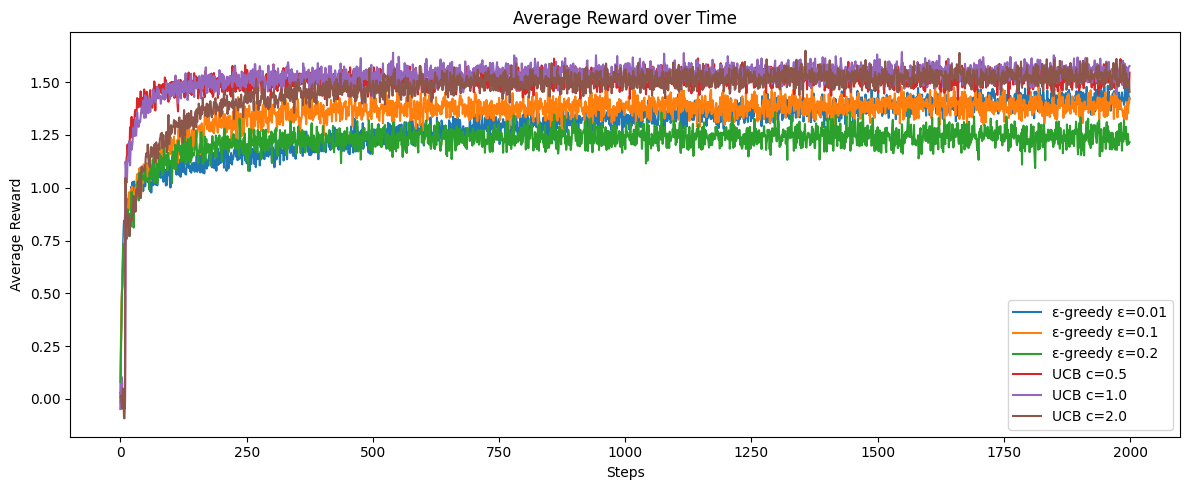

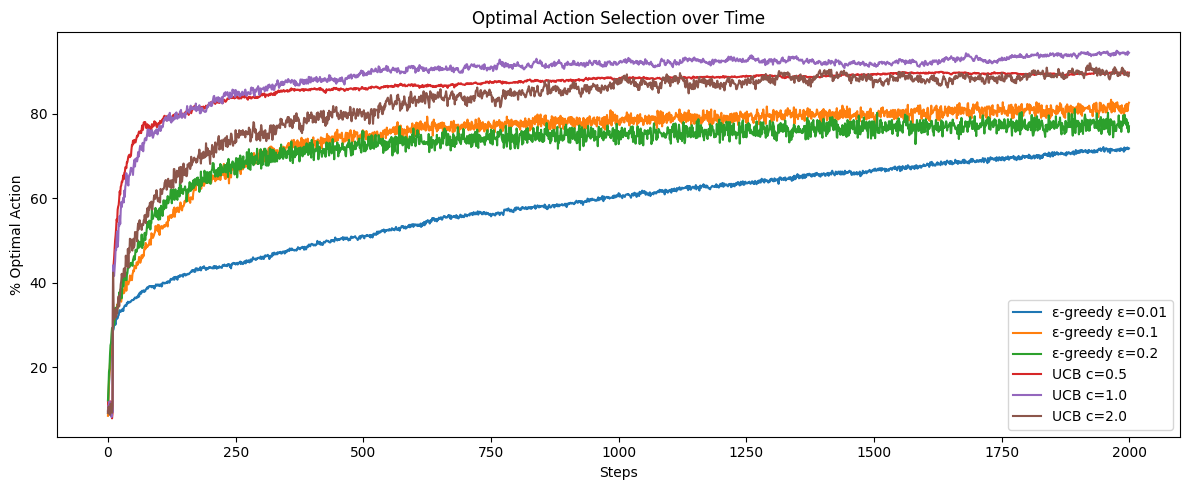

In [36]:
if __name__ == "__main__":
    epsilons = [0.01, 0.1, 0.2]
    ucb_cs   = [0.5, 1.0, 2.0]

    results = {}

    for eps in epsilons:
        label = f"ε-greedy ε={eps}"
        results[label] = run_experiment(EpsilonGreedyAgent, {"epsilon": eps})

    for c in ucb_cs:
        label = f"UCB c={c}"
        results[label] = run_experiment(UCBAgent, {"c": c})

    # ── Plot 1: Average Reward ──
    plt.figure(figsize=(12, 5))
    for label, (avg_r, _) in results.items():
        plt.plot(avg_r, label=label)
    plt.xlabel("Steps")
    plt.ylabel("Average Reward")
    plt.title("Average Reward over Time")
    plt.legend()
    plt.tight_layout()
    plt.savefig("avg_reward.png", dpi=150)
    plt.show()

    # ── Plot 2: % Optimal Action ──
    plt.figure(figsize=(12, 5))
    for label, (_, pct_opt) in results.items():
        plt.plot(pct_opt, label=label)
    plt.xlabel("Steps")
    plt.ylabel("% Optimal Action")
    plt.title("Optimal Action Selection over Time")
    plt.legend()
    plt.tight_layout()
    plt.savefig("pct_optimal.png", dpi=150)
    plt.show()

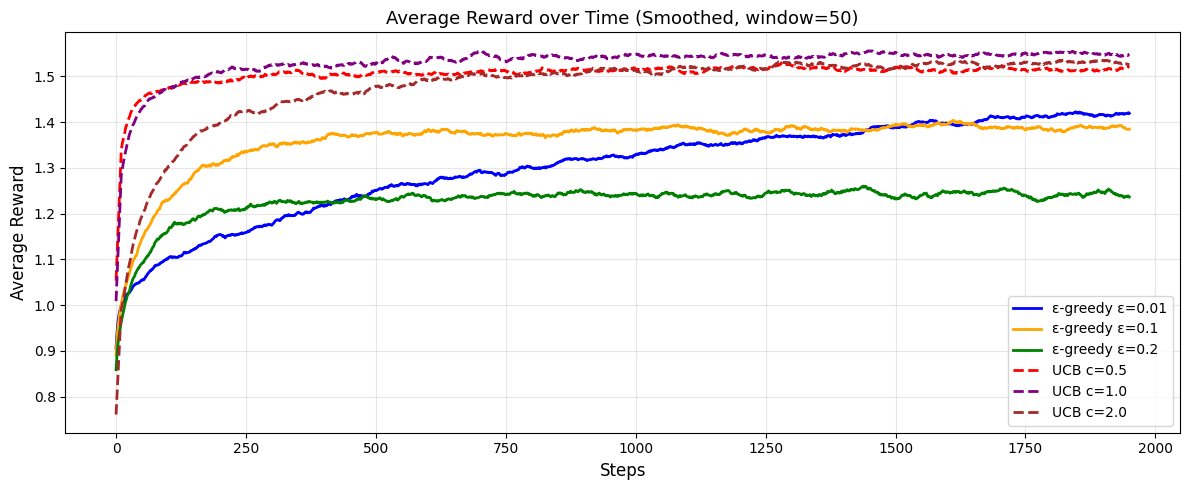

In [37]:
def smooth(data, window=50):
    """Simple moving average smoothing."""
    return np.convolve(data, np.ones(window)/window, mode='valid')

# ── Plot 1: Average Reward (Smoothed) ──
plt.figure(figsize=(12, 5))

styles = {
    "ε-greedy ε=0.01": ("blue",   "-"),
    "ε-greedy ε=0.1":  ("orange", "-"),
    "ε-greedy ε=0.2":  ("green",  "-"),
    "UCB c=0.5":       ("red",    "--"),
    "UCB c=1.0":       ("purple", "--"),
    "UCB c=2.0":       ("brown",  "--"),
}

window = 50
for label, (avg_r, _) in results.items():
    color, ls = styles[label]
    smoothed = smooth(avg_r, window)
    plt.plot(smoothed, label=label, color=color, linestyle=ls, linewidth=2)

plt.xlabel("Steps", fontsize=12)
plt.ylabel("Average Reward", fontsize=12)
plt.title("Average Reward over Time (Smoothed, window=50)", fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("avg_reward_smooth.png", dpi=150)
plt.show()

Running ε-greedy ε=0.01 (1000 runs × 5000 steps)...
Running UCB c=1.0 (1000 runs × 5000 steps)...


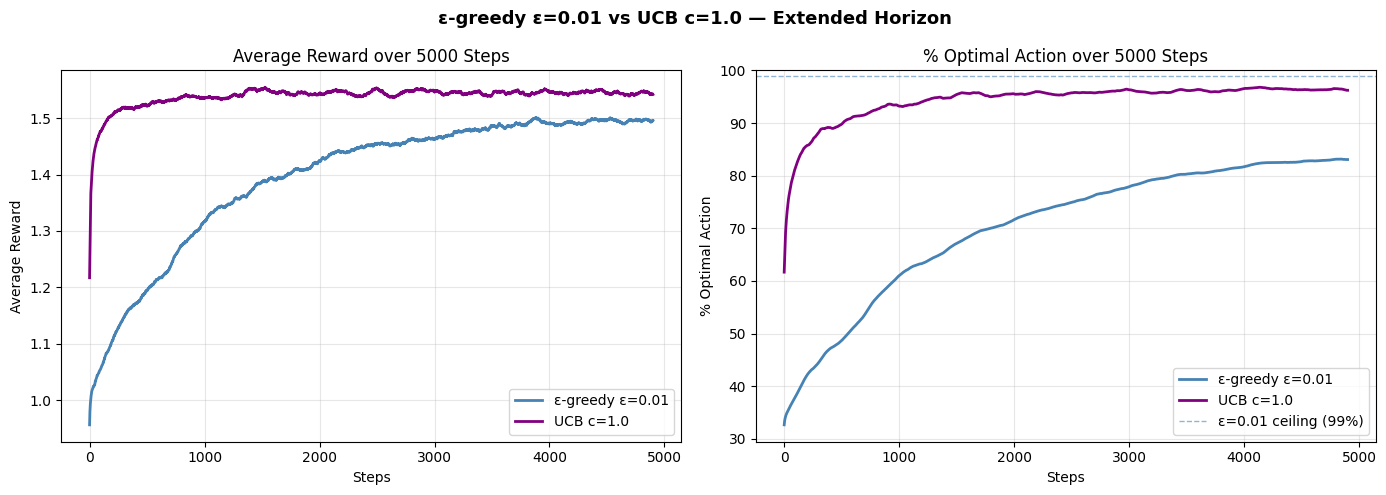

In [67]:
def smooth(data, window=100):
    """Rolling average — wider window for 5000 steps."""
    return np.convolve(data, np.ones(window)/window, mode='valid')

# ── Run only the two curves of interest ──
print("Running ε-greedy ε=0.01 (1000 runs × 5000 steps)...")
r_eps001, o_eps001 = run_experiment(EpsilonGreedyAgent, 
                                     {"epsilon": 0.01}, 
                                     n_runs=1000, n_steps=5000)

print("Running UCB c=1.0 (1000 runs × 5000 steps)...")
r_ucb10, o_ucb10 = run_experiment(UCBAgent, 
                                   {"c": 1.0}, 
                                   n_runs=1000, n_steps=5000)

# ── Plot: side by side ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
window = 100

# Average Reward
axes[0].plot(smooth(r_eps001, window), 
             color='steelblue', linewidth=2, label='ε-greedy ε=0.01')
axes[0].plot(smooth(r_ucb10, window),  
             color='purple',    linewidth=2, label='UCB c=1.0')
axes[0].set_title("Average Reward over 5000 Steps", fontsize=12)
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Average Reward")
axes[0].legend()
axes[0].grid(alpha=0.3)

# % Optimal Action
axes[1].plot(smooth(o_eps001, window), 
             color='steelblue', linewidth=2, label='ε-greedy ε=0.01')
axes[1].plot(smooth(o_ucb10, window),  
             color='purple',    linewidth=2, label='UCB c=1.0')

# Draw the theoretical ceiling for ε=0.01
axes[1].axhline(y=99, color='steelblue', linewidth=1, 
                linestyle='--', alpha=0.6, label='ε=0.01 ceiling (99%)')
axes[1].set_title("% Optimal Action over 5000 Steps", fontsize=12)
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("% Optimal Action")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("ε-greedy ε=0.01 vs UCB c=1.0 — Extended Horizon", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("extended_5000_steps.png", dpi=150)
plt.show()

# Part -2 

In [60]:
import gymnasium as gym

def inspect_environment(env_name):
    """
    Inspect and print MDP components of a Gymnasium environment.
    """
    env = gym.make(env_name)
    obs, info = env.reset()

    print(f"\n{'='*50}")
    print(f"Environment: {env_name}")
    print(f"{'='*50}")

    # TODO: Print observation space type, shape/size
    print(f"Observation Space: ", env.observation_space)

    # TODO: Print action space type and number of actions
    print(f"Action Space: ", env.action_space)

    # TODO: Print a sample observation after reset
    print(f"Sample Observation: {obs}")

    # TODO: Access transition dynamics P[state][action]
    # P gives list of (prob, next_state, reward, terminated)
    # Print first state's transitions for action 0
    print(f"\nSample Transition P[0][0]:", env.unwrapped.P[0][0])
   

    env.close()
    return env




In [58]:
class RandomAgent:
    def __init__(self, action_space):
        self.action_space = action_space

    def select_action(self):
        # TODO: Sample a random action from action space
        return self.action_space.sample()

def evaluate_random_policy(env_name, n_episodes=1000):
    """
    Run random policy for n_episodes.
    Returns episode rewards and lengths.
    """
    env = gym.make(env_name)
    episode_rewards = []
    episode_lengths = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        agent = RandomAgent(env.action_space)
        total_reward = 0
        steps = 0
        terminated = False
        truncated = False

        while not terminated and not truncated:
            action = agent.select_action()
            obs, reward, terminated, truncated, info = env.step(action)
            # TODO: accumulate reward and steps
            total_reward += reward
            steps += 1

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)

    env.close()

    print(f"\n{env_name} Random Policy Results ({n_episodes} episodes):")
    print(f"  Mean Reward:         ", np.mean(episode_rewards) ) # TODO
    print(f"  Std Reward:          ", np.std(episode_rewards))  # TODO
    print(f"  Success Rate:        ", np.mean(np.array(episode_rewards) > 0) * 100)  # TODO: % episodes with reward > 0
    print(f"  Mean Episode Length: ", np.mean(episode_lengths))  # TODO

    return np.array(episode_rewards), np.array(episode_lengths)






In [56]:
# ─────────────────────────────────────────────
# PART 2C: MDP Mapping Documentation
# ─────────────────────────────────────────────

def document_mdp_mapping(env_name):
    env = gym.make(env_name)
    obs, _ = env.reset()

    # Reward descriptions per environment
    reward_descriptions = {
        "FrozenLake-v1": "+1 reaching goal, 0 otherwise",
        "Taxi-v3":       "+20 successful dropoff, -10 wrong pickup/dropoff, -1 per step"
    }

    print(f"\nMDP Mapping for {env_name}:")
    print(f"  S (State space):      {env.observation_space}")
    print(f"  A (Action space):     {env.action_space}")
    print(f"  R (Reward structure): {reward_descriptions[env_name]}")  # 🔧 fixed
    print(f"  P (Transitions):      Stochastic - access via env.unwrapped.P[s][a]")
    print(f"  γ (Discount):         0.99 (agent choice, not in Gym API)")

    env.close()


In [64]:
def plot_random_policy_results(rewards_fl, lengths_fl, rewards_taxi, lengths_taxi):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── FrozenLake ──
    axes[0].plot(np.convolve(rewards_fl, 
                 np.ones(50)/50, mode='valid'), 
                 color='steelblue', linewidth=2)
    axes[0].axhline(y=np.mean(rewards_fl), color='red', 
                    linestyle='--', label=f'Mean={np.mean(rewards_fl):.3f}')
    axes[0].set_title("FrozenLake-v1: Random Policy Reward", fontsize=12)
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Episode Reward")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Taxi ──
    axes[1].plot(np.convolve(rewards_taxi, 
                 np.ones(50)/50, mode='valid'), 
                 color='darkorange', linewidth=2)
    axes[1].axhline(y=np.mean(rewards_taxi), color='red', 
                    linestyle='--', label=f'Mean={np.mean(rewards_taxi):.1f}')
    axes[1].set_title("Taxi-v3: Random Policy Reward", fontsize=12)
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Episode Reward")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle("Random Policy Performance Across Environments", 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("random_policy_results.png", dpi=150)
    plt.show()




Environment: FrozenLake-v1
Observation Space:  Discrete(16)
Action Space:  Discrete(4)
Sample Observation: 0

Sample Transition P[0][0]: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 4, 0, False)]

MDP Mapping for FrozenLake-v1:
  S (State space):      Discrete(16)
  A (Action space):     Discrete(4)
  R (Reward structure): +1 reaching goal, 0 otherwise
  P (Transitions):      Stochastic - access via env.unwrapped.P[s][a]
  γ (Discount):         0.99 (agent choice, not in Gym API)

Environment: Taxi-v3
Observation Space:  Discrete(500)
Action Space:  Discrete(6)
Sample Observation: 231

Sample Transition P[0][0]: [(1.0, 100, -1, False)]

MDP Mapping for Taxi-v3:
  S (State space):      Discrete(500)
  A (Action space):     Discrete(6)
  R (Reward structure): +20 successful dropoff, -10 wrong pickup/dropoff, -1 per step
  P (Transitions):      Stochastic - access via env.unwrapped.P[s][a]
  γ (Discount):         0.99 (agent choice, not in

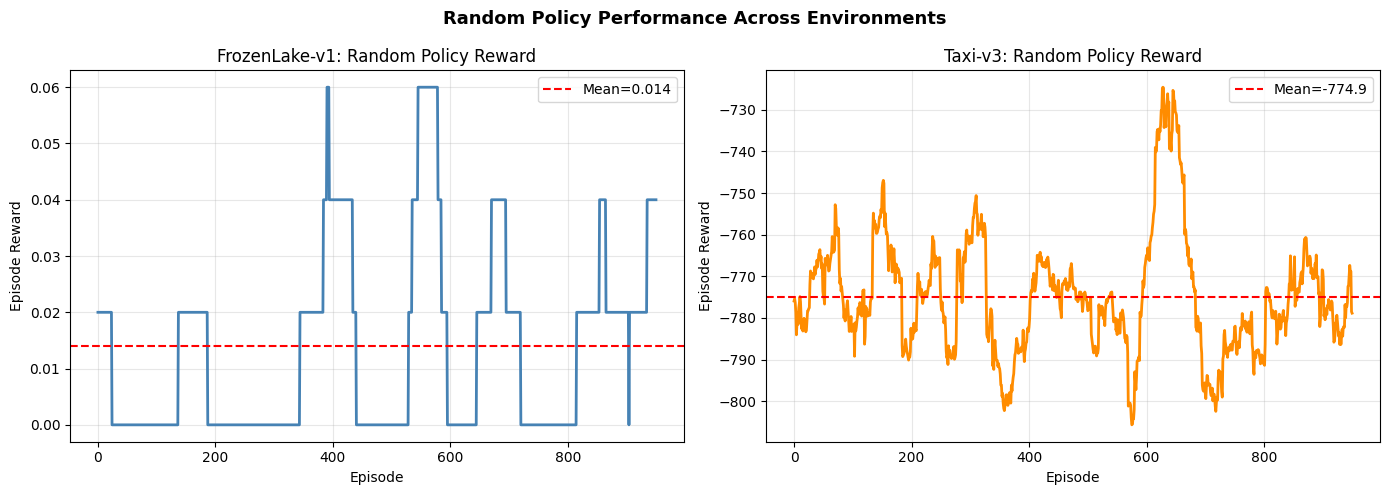

In [65]:
# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":
    for env_name in ["FrozenLake-v1", "Taxi-v3"]:
        inspect_environment(env_name)
        document_mdp_mapping(env_name)

    rewards_fl, lengths_fl   = evaluate_random_policy("FrozenLake-v1")
    rewards_taxi, lengths_taxi = evaluate_random_policy("Taxi-v3")
    plot_random_policy_results(rewards_fl, lengths_fl, rewards_taxi, lengths_taxi)